# Train Main Controller

In [1]:
from wm.controller import Controller
from wm.envs import CONTROLLER_TRAINING_ENV_SPEC
from wm.utils import load_vae, load_rnn
import gymnasium as gym
from flax import nnx
from jaxtyping import Shaped, Array
from wm.agent import Agent

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.13.13)


In [2]:
ENV_ID = "CarRacing-v3"
num_envs = 16

In [3]:
vae_name = "beta1.0"
rnn_path = f"../experiments/rnn/{vae_name}"
vae_path = f"../experiments/vae/{vae_name}"

vae, _ = load_vae(vae_path)
rnn = load_rnn(rnn_path)

In [4]:
controller = Controller(rngs=nnx.Rngs(0))
graphdef, state = nnx.split(controller)
agent = Agent(controller=controller, rngs=nnx.Rngs(0))

In [5]:
from tqdm import trange

from wm.utils import prep_obs
import numpy as np
import jax.numpy as jnp
from evosax.algorithms import CMA_ES as ES
import jax
from einops import rearrange


def prepare_obs(obs: Shaped[np.ndarray, "..."], num_envs: int) -> Shaped[Array, "..."]:
    # TODO: faster to concat and then do a strided read?
    obs = np.array([prep_obs(obs[i]) for i in range(num_envs)])
    return jnp.array(np.float32(obs) / 255.0)

In [6]:
# is there a way to do this without reinstantiating the Agent at each timestep?
# the agent would have to accept a controller in __call__ maybe? and do an nnx merge in __call__
# Or the function itself could just use one agent to do the VAE+RNN step and output the input to the agent

# TODO: don't vmap across the whole thing. Rnn and VAE do batched inference - then the agents are
# vmapped by themselves. Fuck the agent
@nnx.jit
@nnx.vmap(in_axes=(0, None, None, 0, 0, 0))  # vmap across the population
def call_agents(individual, carry, env_states, key):
    model = nnx.merge(graphdef, individual)
    agent = Agent(rngs=nnx.Rngs(key), vae=vae, rnn=rnn, controller=model)
    actions, carry = agent(env_states, carry)  # type: ignore
    return (actions, carry)

In [7]:
from wm.vae import VAE
from wm.rnn import MDNRNN

encode = nnx.jit(VAE.encode)
step_rnn = nnx.jit(MDNRNN.step)


@nnx.jit
@nnx.vmap
def call_controllers(individual, x):
    model: Controller = nnx.merge(graphdef, individual)

    actions = model(x)
    return actions


def compute_fitness(
    population,
    population_size,
    envs,
    num_trials: int = 1,
    base_seed: int = 0,
):
    cum_reward = np.zeros(population_size)
    for trial in trange(num_trials, leave=False):
        carries = rnn.initialize_carry(population_size)
        # Every candidate sees the same track within a trial, so CMA-ES ranks the
        # controllers rather than the luck of their randomly generated track.
        trial_seed = base_seed + trial
        obs, _ = envs.reset(seed=[trial_seed] * population_size)
        active = np.ones(population_size, dtype=bool)
        for _ in range(1000):
            obs = prepare_obs(obs, population_size)
            _, h = carries
            latents = encode(vae, obs).z
            x = jnp.concatenate([latents, h], axis=-1)
            actions = call_controllers(population, x)  # vmap over the controllers.

            rnn_in = jnp.concatenate([latents, actions], axis=-1)
            carries = step_rnn(rnn, rnn_in, carries)

            obs, reward, terminated, truncated, _ = envs.step(np.array(actions))
            cum_reward += reward * active
            active &= ~(terminated | truncated)
            if not active.any():
                break

    # Evosax minimises the fitness. We want to maximise the reward,
    # so return the negative cumulative reward
    return -cum_reward / num_trials

In [9]:
num_generations = 100
population_size = 64
trial_schedule = {0: 2, 15: 4, 25: 8, 50: 16}
num_trials = trial_schedule[0]

# Init env
envs = gym.make_vec(
    CONTROLLER_TRAINING_ENV_SPEC,
    num_envs=population_size,
    vectorization_mode="async",
)

# Init evolutionary strategy
key, init_key = jax.random.split(jax.random.key(0), 2)
es = ES(population_size, solution=state)

es_params = es.default_params
es_state = es.init(init_key, state, es_params)

fitnesses = []
for i in range(num_generations):
    num_trials = trial_schedule.get(i, num_trials)
    key, key_ask, key_tell = jax.random.split(key, 3)
    population, es_state = es.ask(key_ask, es_state, es_params)
    fitness = compute_fitness(
        population,
        population_size,
        envs,
        num_trials,
        base_seed=i * 10_000,
    )
    fitnesses.append(fitness)
    es_state, info = es.tell(key_tell, population, fitness, es_state, es_params)

    print(
        f"Step {i + 1:>2} ({num_trials} trial(s)): "
        f"Best Reward {-info['best_fitness']:.1f}"
    )

Step  1 (2 trial(s)): Best Reward -34.7


Step  2 (2 trial(s)): Best Reward -13.5


Step  3 (2 trial(s)): Best Reward 22.7


Step  4 (2 trial(s)): Best Reward 65.4


Step  5 (2 trial(s)): Best Reward 140.2


...

Step 96 (16 trial(s)): Best Reward 890.2


Step 97 (16 trial(s)): Best Reward 890.2


Step 98 (16 trial(s)): Best Reward 890.2


Step 99 (16 trial(s)): Best Reward 890.2


Step 100 (16 trial(s)): Best Reward 890.2


In [10]:
_, unravel_agent_state = jax.flatten_util.ravel_pytree(state)

best_state = unravel_agent_state(es_state.best_solution)

In [72]:
# observe best agent
envs.close()
n_envs = 64
envs = gym.make_vec(
    ENV_ID,
    num_envs=n_envs,
    vectorization_mode="async",
)

model = nnx.merge(graphdef, best_state)
agent = Agent(rngs=nnx.Rngs(key), vae=vae, rnn=rnn, controller=model)

carry = agent.initialize_carry(num_envs=n_envs)

obs, _ = envs.reset()


cum_reward = np.zeros(n_envs)
active = np.ones(n_envs, dtype=bool)
observations = []
for i in trange(1000, leave=False):
    obs = prepare_obs(obs, n_envs)

    actions, carry = agent(obs, carry)  # type: ignore
    obs, reward, terminated, truncated, _ = envs.step(np.array(actions))
    cum_reward += reward * active
    active &= ~(terminated | truncated)
    observations.append(obs)
    if not active.any():
        break

In [99]:
import mediapy as media

observations = np.array(observations)
idx = 10  # yes it's cherrypicked, but this is a solve!
media.show_video(
    observations[:, idx],
    height=obs.shape[1] * 4,
    width=obs.shape[2] * 4,
    fps=30,
    title=f"Reward: {cum_reward[idx]:.0f}",
)

Reward: 906 This browser does not support the video tag.


In [74]:
print(f"  Mean: {cum_reward.mean():.0f}")
print(f"Median: {np.median(cum_reward):.0f}")
print(f"   Max: {cum_reward.max():.0f}")
print(f"   Min: {cum_reward.min():.0f}")

print("\n All rewards:")
all_rewards = cum_reward.round(0).astype(np.int64)
all_rewards.sort()
print(all_rewards)

  Mean: 821
Median: 858
   Max: 916
   Min: 393

 All rewards:
[393 396 412 507 635 686 701 705 748 749 771 793 796 803 806 812 817 817
 818 821 824 829 830 833 835 840 844 847 847 857 857 858 858 860 862 865
 866 871 874 875 876 879 880 880 885 886 886 890 890 890 896 902 905 906
 906 906 907 907 909 909 910 911 911 916]


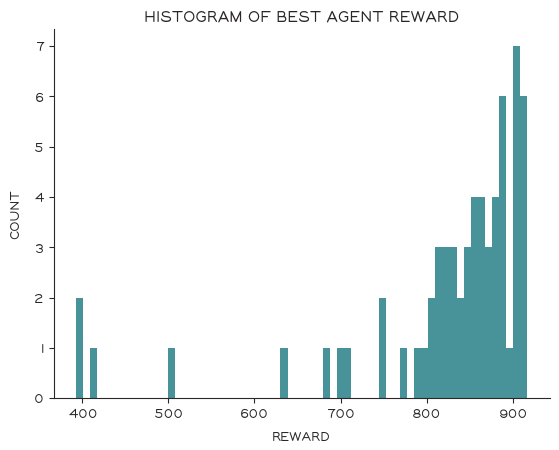

In [75]:
import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")
plt.xlabel("Reward")
plt.ylabel("Count")
plt.title("Histogram of best agent reward")
plt.hist(cum_reward, bins=64);

In [76]:
import numpy as np
from rliable import library as rly
from rliable import metrics

# rliable expects shape: (num_runs, num_tasks)
scores = cum_reward.reshape(-1, 1)

score_dict = {"agent": scores}


# get_interval_estimates expects the metric to return a 1D array
def iqm_fn(x):
    return np.array([metrics.aggregate_iqm(x)])


point_estimates, confidence_intervals = rly.get_interval_estimates(
    score_dict,
    iqm_fn,
    reps=50_000,
    confidence_interval_size=0.95,
    random_state=np.random.RandomState(0),
)

iqm = point_estimates["agent"][0]
ci_lower, ci_upper = confidence_intervals["agent"][:, 0]

print(f"IQM: {iqm:.3f}")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

/Users/alexinch/noodling/world_models_paper/.venv/lib/python3.13/site-packages/arch/bootstrap/base.py:402: FutureWarning: random_state is deprecated and will be removed in a future version. The default random number generator is changing to a NumPy Generator. To continue using RandomState, please directly pass a RandomState instance using the ``generator`` keyword argument.
  warnings.warn(


IQM: 855.208
95% CI: [838.049, 870.487]


In [ ]:
from pathlib import Path

import orbax.checkpoint as ocp

ckpt_dir = Path(f"../experiments/controller/{vae_name}").resolve()

with ocp.StandardCheckpointer() as ckptr:
    ckptr.save(ckpt_dir, best_state)